<h2>Analyst: Alanis Danica P. Concha

<h2>BSIT-3C</h2>

<h1>PROJECT 4: Dengue Cases (Linear Regression)</h1>

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [10]:
dengue = pd.read_csv('Datasets\\dengue.csv')

In [11]:
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [12]:
dengue['Month'] = dengue['Month'].astype('category')
dengue['Year'] = dengue['Year'].astype(int)
dengue['Region'] = dengue['Region'].astype('category')
dengue['Dengue_Cases'] = dengue['Dengue_Cases'].astype(float)
dengue['Dengue_Deaths'] = dengue['Dengue_Deaths'].astype(float)
dengue['Date'] = pd.to_datetime(
    dengue['Year'].astype(str) + '-' + dengue['Month'].astype(str) + '-01',
    errors='coerce'
)

<h2>Did the trend of dengue deaths mainly increase or decrease between 2016 and 2020?</h2>

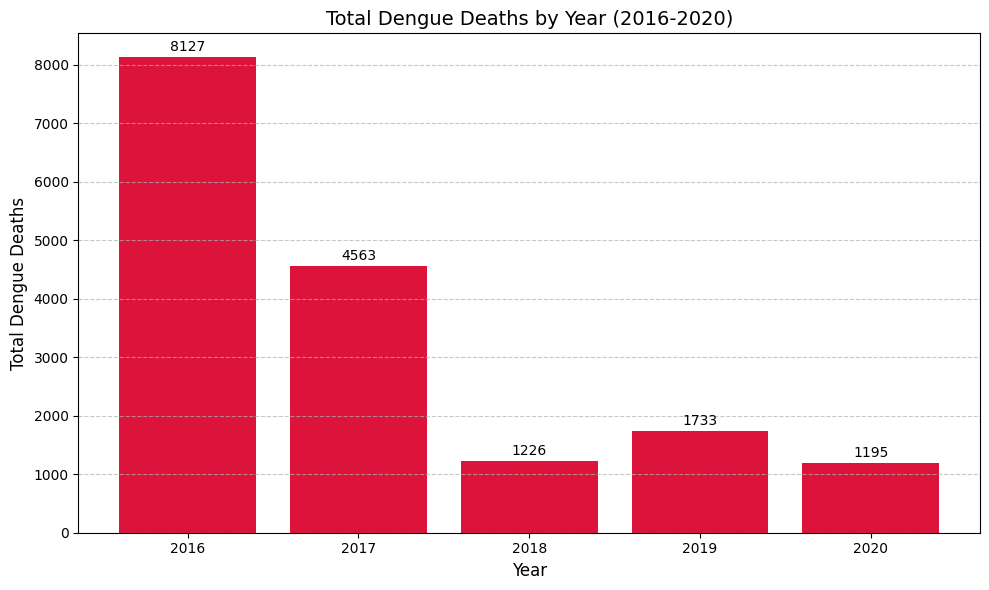

In [13]:
import matplotlib.pyplot as plt

yearly_deaths = dengue.groupby('Year')['Dengue_Deaths'].sum().reset_index()

yearly_deaths.columns = ['Year', 'Total_Dengue_Deaths']

plt.figure(figsize=(10, 6))
bars = plt.bar(yearly_deaths['Year'], yearly_deaths['Total_Dengue_Deaths'], color='crimson')

plt.title('Total Dengue Deaths by Year (2016-2020)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Dengue Deaths', fontsize=12)
plt.xticks(yearly_deaths['Year']) 

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<h2>Insight 1: The recorded data shows a massive overall decrease. Despite a small spike in 2019, the total number of deaths dropped by over 85% from the high of 8,127 in 2016 to the low of 1,195 in 2020. This indicates a successful, fundamental shift in managing or preventing severe dengue cases.</h2>

<h2>Insight 2: While the huge drop is great news, still the number of deaths is not zero. It stays little bit high in the latest years 2018 and 2020. This means the virus is still a persistent, daily danger, and control efforts need to be continuous just to keep the death toll from climbing back up.</h2>

<h2>Which months in Region IV-A are expected to have the highest dengue cases in 2020, and what does this indicate for public health planning?</h2>

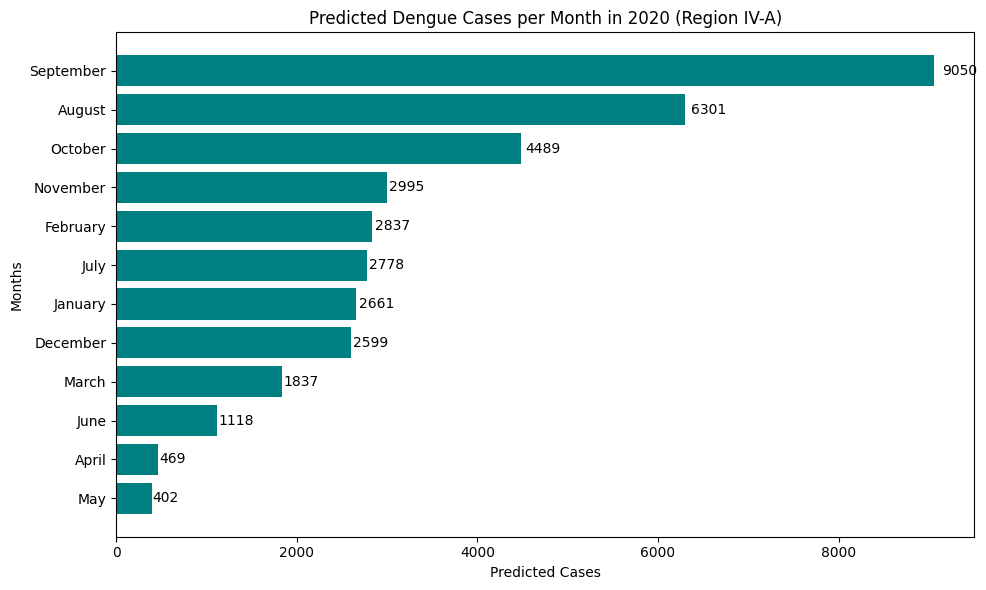

In [14]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

region = "Region IV-A"

predictions = []

months = dengue['Month'].unique()

for month in months:
    df = dengue[(dengue['Region'] == region) & (dengue['Month'] == month)]
    
    if len(df) < 2:
        continue

    X = df[['Year']]
    y = df['Dengue_Cases']

    model = LinearRegression().fit(X, y)

    predicted_value = model.predict([[2020]])[0]

    predictions.append((month, predicted_value))

predictions.sort(key=lambda x: x[1], reverse=True)

plt.figure(figsize=(10,6))
bars = plt.barh(
    [m for m, _ in predictions],
    [v for _, v in predictions],
    color='teal'
)

plt.title("Predicted Dengue Cases per Month in 2020 (Region IV-A)")
plt.xlabel("Predicted Cases")
plt.ylabel("Months")
plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.0f}",
        va='center'
    )

plt.tight_layout()
plt.show()


<h2>Insight 3: Based on the linear regression model, the predicted dengue cases show that September is likely to experience the highest incidence in 2020. This suggests a recurring seasonal trend, meaning dengue outbreaks in Region IV-A are influenced by environmental factors like rainfall and temperature during that month.</h2>

<h2>Insight 4: By knowing which months are at highest risk allows health authorities to focus prevention efforts, such as mosquito control campaigns and community awareness programs, during those specific months to reduce potential outbreaks.</h2>


<h2>Based on historical data from 2016–2019, which months in Region IV-A are projected to have the highest dengue cases and deaths in 2020, and how can this information guide health interventions?</h2>

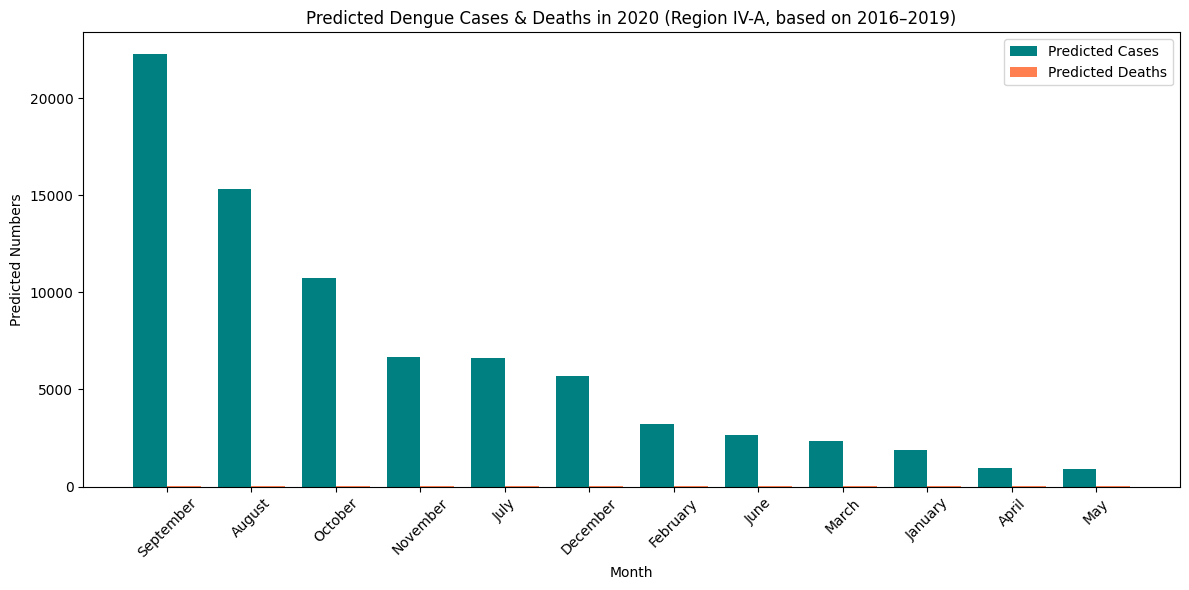

In [15]:
import matplotlib.pyplot as plt

region = "Region IV-A"

years_to_use = [2016, 2017, 2018, 2019]

months = dengue['Month'].unique()

pred_cases = []
pred_deaths = []

for month in months:
    df = dengue[
        (dengue['Region'] == region) &
        (dengue['Month'] == month) &
        (dengue['Year'].isin(years_to_use))
    ]
    
    if len(df) < 2:
        continue 
    
    X = df[['Year']]
    y_cases = df['Dengue_Cases']
    model_cases = LinearRegression().fit(X, y_cases)
    pred_cases.append((month, model_cases.predict([[2020]])[0]))
    
    y_deaths = df['Dengue_Deaths']
    model_deaths = LinearRegression().fit(X, y_deaths)
    pred_deaths.append((month, model_deaths.predict([[2020]])[0]))

pred_cases.sort(key=lambda x: x[1], reverse=True)
pred_deaths.sort(key=lambda x: x[1], reverse=True)

months_cases = [m for m, _ in pred_cases]
cases_values = [v for _, v in pred_cases]

months_deaths = [m for m, _ in pred_deaths]
deaths_values = [v for _, v in pred_deaths]

x = np.arange(len(months_cases))
width = 0.4

plt.figure(figsize=(12,6))
plt.bar(x - width/2, cases_values, width=width, label='Predicted Cases', color='teal')
plt.bar(x + width/2, deaths_values, width=width, label='Predicted Deaths', color='coral')

plt.xticks(x, months_cases, rotation=45)
plt.xlabel("Month")
plt.ylabel("Predicted Numbers")
plt.title("Predicted Dengue Cases & Deaths in 2020 (Region IV-A, based on 2016–2019)")
plt.legend()
plt.tight_layout()
plt.show()


<h2>Insight 5: Using the record from 2016–2019, the model predicts that September will have the highest dengue cases in 2020 in Region IV-A, indicating a strong seasonal pattern.</h2>

<h2>Insight 6: Predicted dengue deaths also peak during month of September, showing that months with the highest cases correspond to increased fatalities, highlighting critical periods for healthcare preparedness. </h2>

<h2>Insight 7: Based also in the record that in the month of April and May is the months that has lowest predicted cases and predicted deaths of dengue. </h2>

<h2>Which regions are expected to experience higher dengue cases in 2021 based on the trends from 2016 to 2020?</h2>

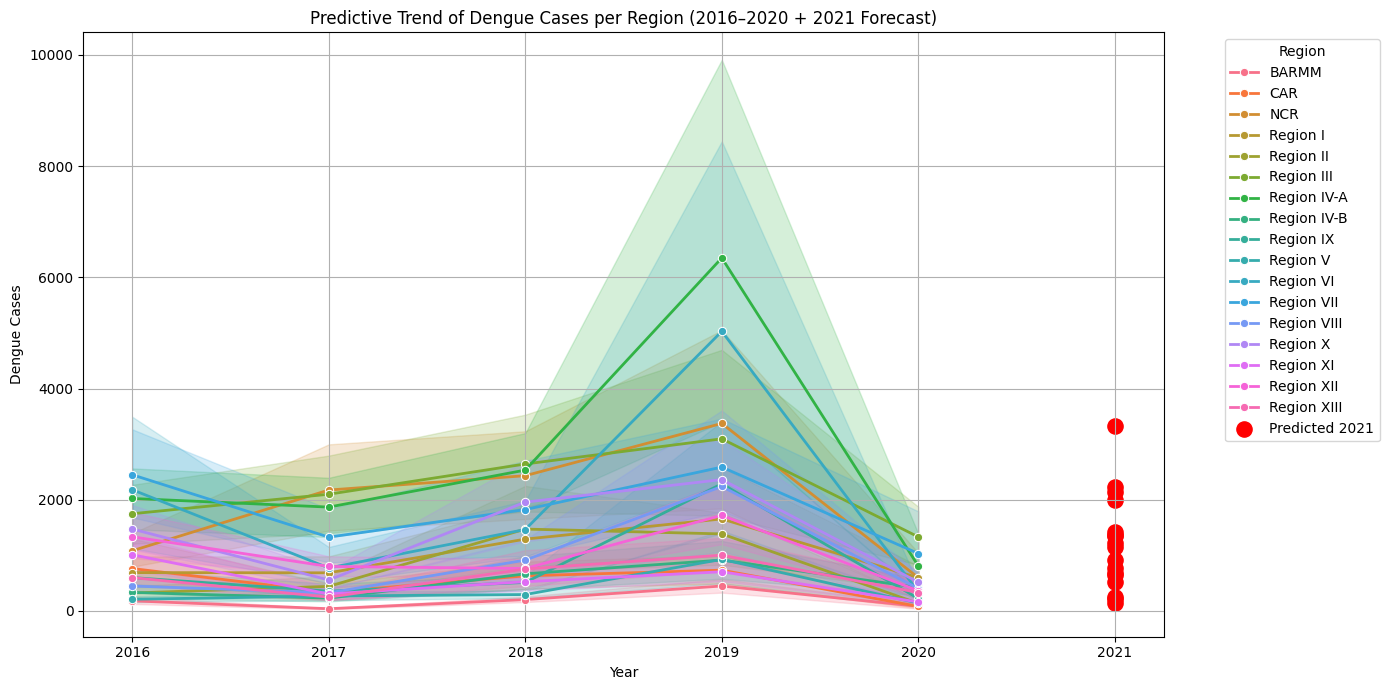

In [16]:
import matplotlib.pyplot as plt

dengue['Year'] = dengue['Year'].astype(int)

regions = dengue['Region'].unique()

predictions = []

for region in regions:
    region_data = dengue[dengue['Region'] == region]

    X = region_data[['Year']]
    y = region_data['Dengue_Cases']

    model = LinearRegression()
    model.fit(X, y)

    predicted_2021 = model.predict([[2021]])[0]

    predictions.append([region, 2021, predicted_2021])

pred_df = pd.DataFrame(predictions, columns=['Region', 'Year', 'Predicted_Cases'])

plt.figure(figsize=(14, 7))

sns.lineplot(data=dengue, x="Year", y="Dengue_Cases", hue="Region", marker="o", linewidth=2)

plt.scatter(pred_df['Year'], pred_df['Predicted_Cases'], s=120, color='red', label="Predicted 2021")

plt.title("Predictive Trend of Dengue Cases per Region (2016–2020 + 2021 Forecast)")
plt.xlabel("Year")
plt.ylabel("Dengue Cases")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021])
plt.grid(True)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


<h2>Insight 8: Based on the visual trend analysis, the regions corresponding to the highest two red dots in the 2021 forecast are expected to experience the highest dengue cases, most likely Region IV-A (CALABARZON) and NCR (National Capital Region), given their historical peaks.</h2>

<h2>Insight 9: The 2021 forecast points is significantly lower than the extreme peak seen in 2019. This suggests a predicted overall decrease in dengue cases across most regions in 2021 compared to the historically high number of cases recorded just two years prior.</h2>

<h2>Insight 10: Also 2021 forecast shows that several regions, like CAR and Region XII, are predicted to have extremely low dengue case counts—close to or below 500 cases. This predicts that the focus of public health intervention would be better served by prioritizing the historically high-incidence areas like Region IV-A and NCR rather than these regions.</h2>